# Basic comparsion of naive and fast convolution

In [1]:
import numpy as np
import sympy as sy
from PIL import Image
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [2]:
from naive_convolve import naive_convolve
from fast_convolution import toom_cook_conv_1d
from utils import plot_pdf, symmetrical_cyclic_convolution

import fast_convolution as fast

In [3]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

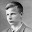

In [4]:
image = Image.open('images/karatsuba032.jpg')
image

In [5]:
feature = np.array(image)
feature.shape

In [6]:
# Laplace discrete operator
w = np.array([
    [ 0, 1, 0],
    [ 1, -4, 1],
    [ 0, 1, 0],
])
w

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [7]:
wr = w[::-1, ::-1]
wr

array([[ 0,  1,  0],
       [ 1, -4,  1],
       [ 0,  1,  0]])

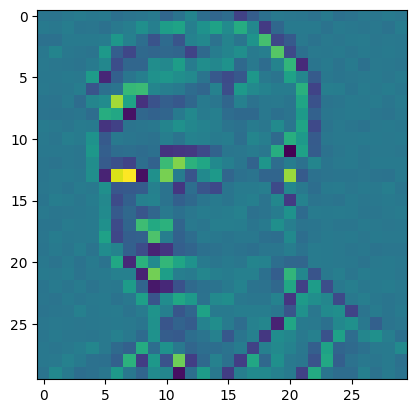

In [8]:
output = signal.convolve2d(feature, wr, mode='valid')
plt.imshow(output)

Running naive convolution
9 multiplications and 8 aditions per output scalar

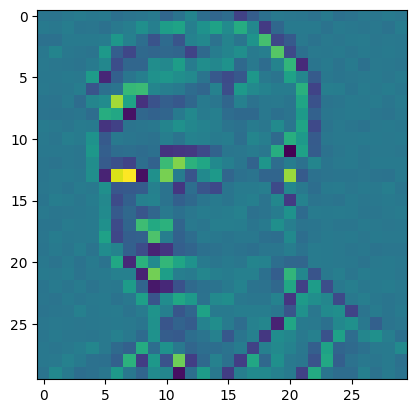

In [9]:
output_naive = naive_convolve(feature, w)
plt.imshow(output_naive)

In [10]:
np.all(output == output_naive)

True

Fast convolution need to reverse the features order

In [11]:
feat = np.fliplr(feature)
feat

array([[152, 152, 154, ..., 124, 120, 118],
       [161, 157, 156, ..., 127, 125, 119],
       [159, 156, 161, ..., 127, 126, 122],
       ...,
       [166, 171, 169, ..., 124, 124, 121],
       [168, 178, 176, ..., 125, 127, 122],
       [177, 182, 180, ..., 150, 127, 120]], dtype=uint8)

Init Tap filter from fast 1d convolution method with 5 multiplications, 20 aditions and 9 extras operations, 5 input and 3 output per batch

In [12]:
fast_conv = toom_cook_conv_1d(3, 3, [0, -1, 1, -2, np.inf], w[0])

The tap filter work in batch mode and the output is reversed

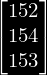

In [13]:
fast_conv(feat[0, :5])

In [14]:
fast_conv = [toom_cook_conv_1d(3, 3, [0, -1, 1, -2, np.inf], w[i]) for i in range(3)]

In [ ]:
pad = 0


In [47]:
out0 = []
for r in range(0, feat.shape[0]):
    for c in range(0, feat.shape[1], 3):
        f = feature[r, c:c+2]
        if len(f) == 5:
            out = fast_conv[0](f).flat()
            out0.append(out)
        # else:
        #     zeros = (5 - len(f)) * [0]
        #     out = fast_conv[0](f.tolist() + zeros).flat()
        # out0.append(out)

out0 = np.array(out0)

In [57]:
out0.reshape(-1, 32)[::, 1]

array([0, 125, 0, 0, 162, 0, 0, 150, 0, 0, 147, 0, 0, 82, 0, 0, 139, 0, 0,
       142, 0, 0, 110, 0, 0, 194, 0, 0, 130, 0, 0, 155, 0], dtype=object)

In [53]:
out0[0]

array([120, 0, 0], dtype=object)

How join multiple 1d convolution in one 2d convolution

Sum results in the first dimension

In [22]:
output_fast = np.sum([out0, out1, out2], axis=0)
output_fast

NameError: name 'out0' is not defined

In [23]:
np.all(output_fast == output_naive)

NameError: name 'output_fast' is not defined

Camparing how much operations are used in naive and fast method

Output Size

In [24]:
size = output.size
size

Naive: total of multiplications

In [25]:
size * 9

Naive: total of additions

In [26]:
size * 8

Fast: total of multiplications

In [27]:
size * 5

Fast: additions for each batch processed

In [28]:
add0 = size * 20
add0

Fast: additions to join batches

In [29]:
add1 = size * 2
add1

Fast: Total of additions

In [30]:
add0 + add1

Fast: total of extra operations - bit shifts and etc

In [31]:
size * 9